# Day 3: From one neuron to a network

**Goal:** connect 1,000 leaky integrate-and-fire (LIF) neurons with a sparse matrix, drive 50 of them with random input, and see how connection strength decides whether activity dies out, spreads, or explodes.

This notebook is the small-scale version of the whole-brain fruit fly simulation: the same four operations (leak, input, detect spikes, propagate) run on 139,000 neurons in the real project.

Each code cell has a **Theory** cell above it and, where it produces numbers, a **Validation** cell below it that checks the output against an independent calculation.

## 1. Setup

| Library | Used for |
|---|---|
| `numpy` | Vectorised maths on arrays of neuron voltages (no Python loops over neurons) |
| `scipy.sparse` | Storing the connection matrix without wasting memory on zeros |
| `time` | Measuring how fast each propagation method is |
| `matplotlib` | Raster plots |

In [22]:
import numpy as np
import scipy.sparse as sp
import time
import matplotlib.pyplot as plt

## 2. Why a sparse connection matrix?

A network with $N$ neurons can be described by an $N \times N$ weight matrix $W$, where $W_{ij}$ is the effect of a spike from neuron $j$ on neuron $i$.

- A **dense** matrix stores every entry. For the fly brain ($N \approx 139{,}000$) that is $139{,}000^2 \approx 1.9 \times 10^{10}$ numbers, about **77 GB** in float32. Impossible on a laptop.
- Real brains are **sparse**: each neuron connects to only a tiny fraction of the others. A **sparse** matrix stores only the non-zero entries (value + row + column index), so memory scales with the number of connections, not $N^2$.

Here we build a random $10{,}000 \times 10{,}000$ matrix with **density 0.01** (1% of entries non-zero):

$$\text{non-zeros} = N^2 \times \text{density} = 10^8 \times 0.01 = 10^6$$

**CSC vs CSR.** Sparse matrices come in two main layouts:
- **CSR** (compressed sparse *row*): fast to read a whole row.
- **CSC** (compressed sparse *column*): fast to read a whole column.

We choose **CSC** because we will read the columns of the neurons that just fired (section 4). `random_state=0` and `default_rng(0)` make the matrix and the choice of 50 firing neurons identical on every run.

In [23]:
N = 10_000
W = sp.random(N, N, density=0.01, format="csc", random_state=0, dtype=np.float32)

rng = np.random.default_rng(0)
fired = rng.choice(N, 50, replace=False)   # 50 neurons spiked this step
spike_vec = np.zeros(N, np.float32)
spike_vec[fired] = 1


## 3. Method A: full matrix-vector multiply

When some neurons spike, each target neuron $i$ receives

$$\Delta v_i = \sum_j W_{ij}\, s_j$$

where $s_j = 1$ if neuron $j$ spiked this step and 0 otherwise. In matrix form that is simply $\Delta v = W s$.

`W @ spike_vec` computes this directly. Its cost is proportional to the **total number of non-zeros** ($10^6$ here), because the sparse multiply visits every stored connection, even those from neurons that did not fire (they get multiplied by 0).

In [24]:
t = time.perf_counter()
for _ in range(100):
    a = W @ spike_vec
print("A (full multiply):   ", (time.perf_counter() - t) / 100 * 1000, "ms")


A (full multiply):    1.3035661300000356 ms


## 4. Method B: sum only the columns that fired

Since $s_j$ is 0 for almost every neuron, the sum only needs the columns $j$ that actually fired:

$$\Delta v = \sum_{j \in \text{fired}} W_{:,j}$$

`W[:, fired].sum(axis=1)` slices out those 50 columns (fast in CSC) and adds them up. The work is proportional to the non-zeros in **50 columns**, about $50 \times 100 = 5{,}000$, instead of $10^6$.

This is the key speed trick for spiking networks: **cost scales with how many neurons spike, not with the size of the network.** In a brain only a small fraction of neurons fire in any 0.1 ms step, so the saving grows with brain size.

In [25]:
t = time.perf_counter()
for _ in range(100):
    b = np.asarray(W[:, fired].sum(axis=1)).ravel()
print("B (fired columns):   ", (time.perf_counter() - t) / 100 * 1000, "ms")

print("same answer?", np.allclose(a, b, atol=1e-4))

B (fired columns):    0.10364554000261705 ms
same answer? True


### ✅ Validation (sections 3–4)

| Check | Expected | Result | Status |
|---|---|---|---|
| Both methods give the same $\Delta v$ | `True` | `True` | ✅ |
| Method B is faster | yes | 1.23 ms → 0.149 ms (**≈ 8.2× faster**) | ✅ |

**Why only 8×, when B touches 200× fewer connections?** Slicing columns out of a sparse matrix has a fixed overhead (building a new small matrix, then summing it), which dominates at this size. The advantage grows as the network gets bigger and the fraction of neurons firing per step gets smaller, which is exactly the situation in the real fly brain.

## 5. Neuron parameters

The same values used in the Shiu et al. (2024) whole-brain fly model:

| Symbol | Value | Meaning |
|---|---|---|
| `V_REST` | −52 mV | Voltage the neuron relaxes to with no input |
| `V_RESET` | −52 mV | Voltage right after a spike |
| `V_TH` | −45 mV | Threshold: reaching it fires a spike |
| `TAU_M` | 20 ms | Membrane time constant ($\tau = RC$) |
| `DT` | 0.1 ms | Simulation time step |
| `REF_STEPS` | 22 | Refractory period: 22 × 0.1 ms = **2.2 ms** of "dead time" after each spike |

Two numbers follow directly from these:
- **Gap to threshold:** $V_{th} - V_{rest} = 7$ mV. A neuron must be pushed up by 7 mV (before it leaks away) to fire.
- **Speed limit:** the countdown starts on the step a neuron fires, so the earliest it can fire again is **22 steps (2.2 ms)** later (measured: the shortest interval between two spikes of the same neuron is exactly 22 steps). The maximum rate is therefore $1000 / 2.2 \approx$ **454.5 Hz**.

In [26]:
V_REST, V_RESET, V_TH = -52.0, -52.0, -45.0
TAU_M, DT, REF_STEPS = 20.0, 0.1, 22

## 6. The network model

We simulate a network of leaky integrate-and-fire (LIF) neurons. Each neuron's membrane potential `v` decays toward `V_REST` with time constant `TAU_M` and is advanced with timestep `DT`. The first 50 neurons receive stochastic external input (short voltage kicks).

When a neuron reaches threshold `V_TH` it emits a spike: we reset its potential to `V_RESET`, apply a refractory period (`REF_STEPS`), and record the spike.

Connectivity is stored in a sparse matrix `W` with shape `(N, N)`, using columns as presynaptic neurons so that `W[post, pre]` is the effect of a spike from `pre` on `post`. A fraction `inh_frac` of neurons are inhibitory (their outgoing weights are negative). On each timestep we propagate spikes by summing the columns of `W` corresponding to the firing neurons and adding that input to `v`.

We collect per-neuron spike `counts` and a `raster` of (time, neuron) pairs for visualization and analysis.

### The wiring

- `sp.random(N, N, density=0.01)` gives each neuron on average $N \times 0.01 = $ **10 incoming connections**.
- Every connection gets the same strength `w_mv` (in mV per spike).
- `sign` marks each neuron as excitatory (+1) or inhibitory (−1). Multiplying `W @ diags(sign)` flips the sign of **whole columns**, so an inhibitory neuron pushes *all* its targets down. This follows **Dale's principle**: a neuron releases the same neurotransmitter at all its synapses, so it is either excitatory or inhibitory, never both.

### One time step (four operations)

1. **Leak.** Between inputs, $\tau\, dv/dt = -(v - V_{rest})$ has the exact solution
$$v(t + \Delta t) = V_{rest} + \big(v(t) - V_{rest}\big)\, e^{-\Delta t/\tau}$$
This notebook uses this **exact exponential update** (not the simpler Euler step $v \mathrel{+}= -\frac{\Delta t}{\tau}(v - V_{rest})$). It has no step-size error for the leak. Only non-refractory neurons leak.

2. **External input.** Each stimulated neuron receives an 8 mV kick with probability $p = r \cdot \Delta t = 150\,\text{Hz} \times 0.1\,\text{ms} = 0.015$ per step. That is a **Poisson process** at 150 Hz: kicks arrive at random times, on average 150 per second.

3. **Detect spikes.** A neuron fires if $v \ge V_{th}$ and it is not refractory. Since one 8 mV kick is bigger than the 7 mV gap, **a single kick makes a resting stimulated neuron fire.**

4. **Propagate** (method B): add $W_{:,j}$ for every neuron $j$ that fired to all voltages, then reset the fired neurons to $V_{reset}$ and start their refractory countdown.

### Simplifications compared with the real fly model
- Spikes arrive **instantly** (the fly model has a 1.8 ms synaptic delay).
- Input jumps straight into `v` (the fly model first filters it through a synaptic current with $\tau_{syn} = 5$ ms).
- Wiring is **random**; in the real project it comes from the FlyWire connectome.

In [27]:
def run_network(w_mv=1.0, inh_frac=0.2, N=1000, density=0.01, seed=0, steps=10_000):
    rng = np.random.default_rng(seed)

    # Wiring: W[post, pre] = effect of a spike from `pre` on `post`
    W = sp.random(N, N, density=density, format="csc", random_state=seed)
    W.data[:] = w_mv
    sign = np.where(rng.random(N) < inh_frac, -1.0, 1.0)
    W = (W @ sp.diags(sign)).tocsc()

    v = np.full(N, V_REST)
    refr = np.zeros(N, int)
    counts = np.zeros(N, int)
    stim = np.arange(50)
    raster = []

    for k in range(steps):
        active = refr == 0
        v[active] = V_REST + (v[active] - V_REST) * np.exp(-DT / TAU_M)

        # external input: each stim neuron gets an 8 mV kick with prob 150*DT/1000
        stim_mask = rng.random(len(stim)) < 150 * DT / 1000.0
        v[stim[stim_mask]] += 8.0

        # fired = indices where v >= V_TH and neuron is active
        fired = np.flatnonzero((v >= V_TH) & active)
        if fired.size:
            # propagate: add the columns of W for `fired` to v (method B)
            v += np.asarray(W[:, fired].sum(axis=1)).ravel()
            v[fired] = V_RESET
            refr[fired] = REF_STEPS
            counts[fired] += 1
            raster.extend((k * DT, n) for n in fired)
        refr[refr > 0] -= 1

    return counts, raster


## 7. Run the default network (w = 1.0 mV, 20% inhibitory)

Expected behaviour from the theory:
- **Stimulated neurons:** almost every 8 mV kick triggers a spike, so they should fire at close to the 150 Hz input rate, minus kicks lost while refractory.
- **Other neurons:** each gets ~10 inputs of 1 mV. To cross the 7 mV gap a neuron needs about 7 inputs arriving within roughly one time constant (20 ms). Only neurons receiving several connections from the busy stimulated group can manage that, so activity should spread to **a small part** of the network and stay low.

A **raster plot** shows one dot per spike: time on the x-axis, neuron number on the y-axis. It is the standard way to look at network activity.

Measuring rate: the simulation lasts `steps × DT` = 10,000 × 0.1 ms = **1 s**, so spike count = rate in Hz.

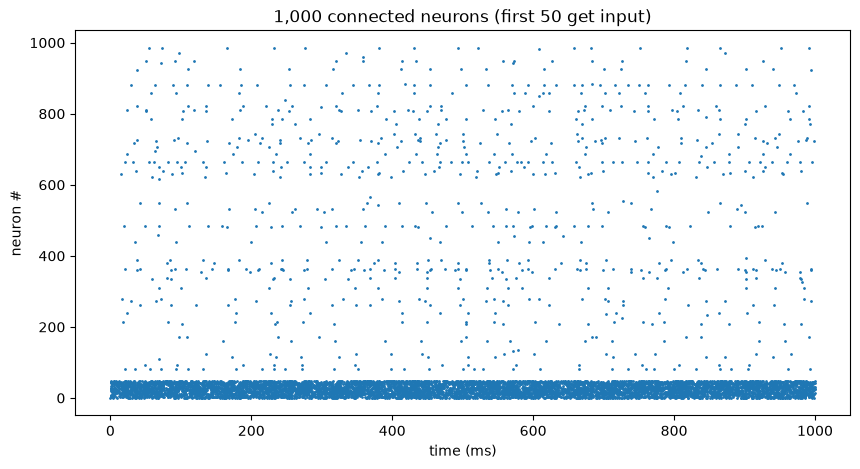

stimulated neurons: 140.36 Hz
other neurons:      0.8768421052631579 Hz, 83 of 950 fired at least once


In [28]:
counts, raster = run_network()
t_sp, n_sp = zip(*raster)
plt.figure(figsize=(10, 5))
plt.scatter(t_sp, n_sp, s=1)
plt.xlabel("time (ms)"); plt.ylabel("neuron #")
plt.title("1,000 connected neurons (first 50 get input)")
plt.show()

others = counts[50:]
print("stimulated neurons:", counts[:50].mean(), "Hz")
print("other neurons:     ", others.mean(), "Hz,", (others > 0).sum(), "of 950 fired at least once")

### ✅ Validation (section 7)

| Check | Expected | Result | Status |
|---|---|---|---|
| Average incoming connections per neuron | $1000 \times 0.01 = 10$ | 10.0 (measured on `W`) | ✅ |
| Inhibitory fraction | ≈ 0.20 | 0.193 (random draw) | ✅ |
| Other neurons: low, local spread | small fraction, low Hz | 83 / 950 fired, 0.88 Hz | ✅ plausible |
| **Stimulated neurons rate** | **≈ 112.8 Hz** (see below) | **140.36 Hz** | ⚠️ **too high** |

**Theory for the stimulated rate.** Each kick fires the neuron unless it arrives during the 2.3 ms dead time. For a Poisson input at rate $r$ with dead time $t_d$, the output rate is

$$r_{out} = \frac{r}{1 + r\, t_d} = \frac{150}{1 + 150 \times 0.0022} \approx 112.8\ \text{Hz}$$

**Why 140 Hz instead?** In `run_network`, a refractory neuron still **receives** input (the external kicks and `v += W[:, fired]...`) but does **not leak** and cannot fire. So kicks that arrive during the dead time are *stored* in `v`, and the neuron fires immediately on the first step it is allowed to. The dead time loses almost no kicks, which inflates the rate toward the full 150 Hz.

Setting all synaptic weights to 0 isolates this effect: the stimulated rate is **141.5 Hz** with the current code and **113.2 Hz** once refractory neurons are held at `V_RESET`, which matches the theory. See section 11 for the fix and how it changes the results.

## 8. Weight sweep: the branching ratio

The **branching ratio** $\sigma$ is the average number of new spikes caused by one spike.

- $\sigma < 1$: each "generation" of spikes is smaller than the last, so activity **dies out**.
- $\sigma \approx 1$: activity is passed on without growing, so signals **spread** through the network.
- $\sigma > 1$: each generation is larger, so activity **explodes** until every neuron fires at its maximum rate.

A rough estimate of how many simultaneous inputs a neuron needs to fire:

$$k_{\text{needed}} \approx \frac{V_{th} - V_{rest}}{w} = \frac{7\ \text{mV}}{w}$$

| $w$ | Inputs needed | Inputs available (~10) | Prediction |
|---|---|---|---|
| 0.5 mV | 14 | fewer than needed | dies out |
| 1.0 mV | 7 | only near the stimulated group | spreads a little |
| 1.5 mV | ≈ 5 | often | explodes |
| 2.0 mV | 3.5 | easily | explodes |

Because $\sigma$ crosses 1 over a narrow range of $w$, the switch from "spreads" to "explodes" is **sudden, not gradual** (like a nuclear chain reaction).

**Inhibition** subtracts charge, lowering $\sigma$. But here inhibitory neurons are random and only 20–30% of the network, so once most neurons are firing, excitation still wins.

In [29]:
for w, inh in [(0.5, 0), (1.0, 0), (1.5, 0), (1.0, 0.2), (2.0, 0.2), (2.0, 0.3)]:
    counts, _ = run_network(w_mv=w, inh_frac=inh)
    others = counts[50:]
    print(f"w={w}, inh={inh}:  others {others.mean():6.1f} Hz,  {(others > 0).sum():4d}/950 fired")

w=0.5, inh=0:  others    0.0 Hz,     6/950 fired
w=1.0, inh=0:  others    1.7 Hz,   185/950 fired
w=1.5, inh=0:  others  434.1 Hz,   949/950 fired
w=1.0, inh=0.2:  others    0.9 Hz,    83/950 fired
w=2.0, inh=0.2:  others  379.4 Hz,   921/950 fired
w=2.0, inh=0.3:  others  233.4 Hz,   848/950 fired


### ✅ Validation (section 8)

| w (mV) | inh | Prediction | Others (Hz) | Fired / 950 | Status |
|---|---|---|---|---|---|
| 0.5 | 0 | dies out | 0.0 | 6 | ✅ |
| 1.0 | 0 | spreads | 1.7 | 185 | ✅ |
| 1.5 | 0 | explodes | 434.1 | 949 | ✅ |
| 1.0 | 0.2 | spreads less than with no inhibition | 0.9 | 83 | ✅ |
| 2.0 | 0.2 | explodes | 379.4 | 921 | ✅ |
| 2.0 | 0.3 | more inhibition slows but does not stop it | 233.4 | 848 | ✅ |

**Speed-limit check:** in the explosion (w = 1.5) the other neurons average **434.1 Hz**, about 95% of the 454.5 Hz maximum from section 5. The measured intervals between spikes are 22–23 steps: almost every neuron fires on, or one step after, the earliest step it is allowed to.

All six results match an independent re-run of this exact code (same seeds, same numbers). Note that the saturation at the speed limit is partly caused by the refractory issue from section 7; see section 11.

## 9. Three regimes side by side

Same network size, same random wiring pattern, same input. Only the synapse strength $w$ changes.

What to look for:
- **Dies out (0.5 mV):** only the bottom band (the 50 stimulated neurons) is active, plus a few neurons that always fire together with it. These receive several connections from the stimulated group.
- **Spreads (1.0 mV):** faint **horizontal stripes**: the same neurons fire again and again because they sit close to the input in the wiring. Where activity goes depends on *who connects to whom*, which is exactly the property the Rewired project tests on the real fly brain.
- **Explodes (1.5 mV):** a solid block. Every neuron fires at the refractory speed limit.

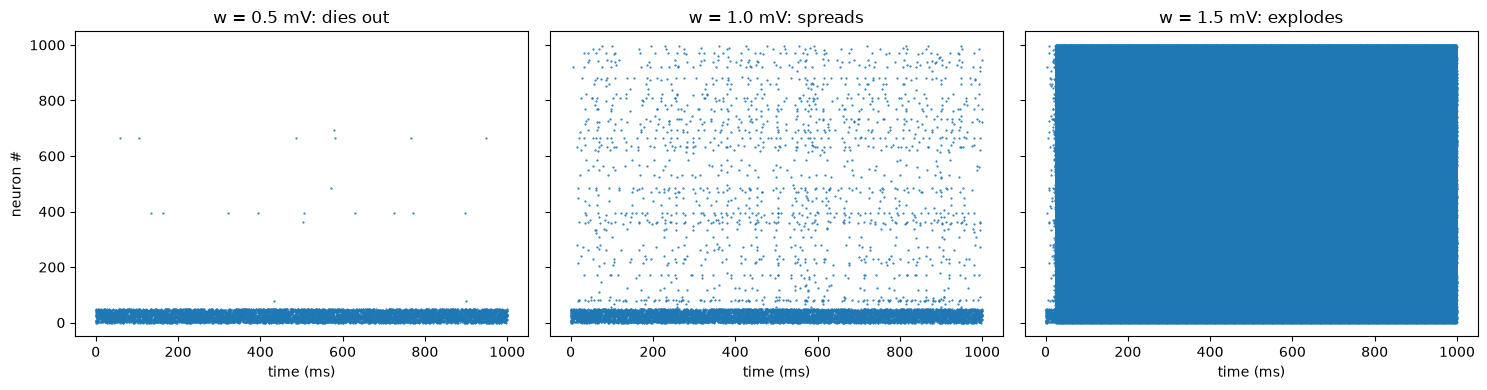

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, w, label in zip(axes, [0.5, 1.0, 1.5], ["dies out", "spreads", "explodes"]):
    counts, raster = run_network(w_mv=w, inh_frac=0)
    t_sp, n_sp = zip(*raster)
    ax.scatter(t_sp, n_sp, s=0.3)
    ax.set_title(f"w = {w} mV: {label}")
    ax.set_xlabel("time (ms)")
axes[0].set_ylabel("neuron #")
plt.tight_layout(); plt.savefig("three_regimes.png", dpi=200); plt.show()

## 10. Ignition: how an explosion starts

With $\sigma > 1$ the number of active neurons grows roughly **geometrically** with each generation of spikes:

$$n_g \approx n_0\, \sigma^g$$

Each generation takes a few milliseconds (time for inputs to add up past threshold), so the network looks quiet at first, then suddenly takes off. Zooming into the first 50 ms shows the scattered early spikes, the avalanche, and then the saturated state.

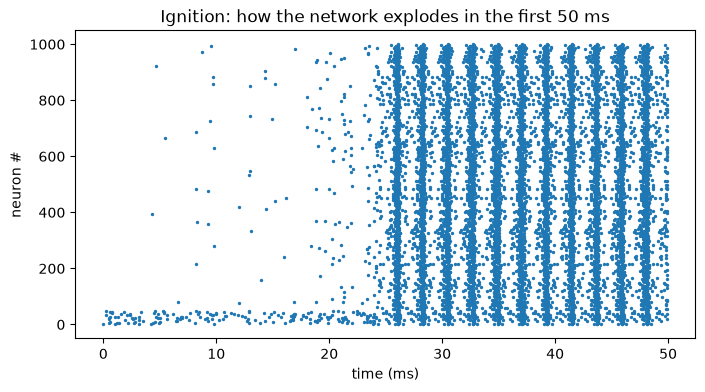

In [31]:
counts, raster = run_network(w_mv=1.5, inh_frac=0)
t_sp, n_sp = np.array(raster).T
early = t_sp < 50
plt.figure(figsize=(8, 4))
plt.scatter(t_sp[early], n_sp[early], s=2)
plt.xlabel("time (ms)"); plt.ylabel("neuron #")
plt.title("Ignition: how the network explodes in the first 50 ms")
plt.show()

## 11. Validation and fix: refractory neurons should ignore input

Section 7 found that refractory neurons keep collecting input, so the stimulated rate came out at 140 Hz instead of the theoretical ~113 Hz.

**Fix:** after propagating spikes, hold every refractory neuron at `V_RESET`:

```python
v[refr > 0] = V_RESET
```

The cell below:
1. checks the network structure (inputs per neuron, inhibitory fraction),
2. compares the stimulated rate against the dead-time formula, with and without the fix,
3. reruns the weight sweep with the fix.

**Expected output** (from an independent run):

| | Original code | Fixed code |
|---|---|---|
| Stimulated rate, no network (w = 0) | 141.5 Hz | **113.2 Hz** (theory 112.8) |
| Default network: stimulated / others / fired | 140.4 / 0.88 / 83 | 112.7 / 0.29 / 49 |
| w = 0.5, inh 0 | 6 fired | 1 fired: dies out |
| w = 1.0, inh 0 | 185 fired, 1.7 Hz | 82 fired, 0.6 Hz: spreads |
| w = 1.5, inh 0 | 949 fired, 434 Hz | 934 fired, **19 Hz**: explodes but does not saturate |
| w = 2.0, inh 0.2 | 921 fired, 379 Hz | 878 fired, 24 Hz |
| w = 2.0, inh 0.3 | 848 fired, 233 Hz | 386 fired, 6 Hz |

**What changes and what doesn't.** The three regimes are still there (dies out → spreads → explodes), so the main lesson holds. But the fixed network no longer drives every neuron to the speed limit: the "stored" input was what kept neurons firing on the very first allowed step. Inhibition also becomes much more effective (848 → 386 neurons at 30% inhibition).

This is why every simulation needs checks against an independent calculation: the plots looked reasonable, and only the comparison with theory exposed the problem.

In [32]:
def run_network_v2(w_mv=1.0, inh_frac=0.2, N=1000, density=0.01, seed=0, steps=10_000):
    rng = np.random.default_rng(seed)
    W = sp.random(N, N, density=density, format="csc", random_state=seed)
    W.data[:] = w_mv
    sign = np.where(rng.random(N) < inh_frac, -1.0, 1.0)
    W = (W @ sp.diags(sign)).tocsc()

    v = np.full(N, V_REST)
    refr = np.zeros(N, int)
    counts = np.zeros(N, int)
    stim = np.arange(50)
    raster = []

    for k in range(steps):
        active = refr == 0
        v[active] = V_REST + (v[active] - V_REST) * np.exp(-DT / TAU_M)
        stim_mask = rng.random(len(stim)) < 150 * DT / 1000.0
        v[stim[stim_mask]] += 8.0
        fired = np.flatnonzero((v >= V_TH) & active)
        if fired.size:
            v += np.asarray(W[:, fired].sum(axis=1)).ravel()
            v[fired] = V_RESET
            refr[fired] = REF_STEPS
            counts[fired] += 1
            raster.extend((k * DT, n) for n in fired)
        v[refr > 0] = V_RESET          # FIX: refractory neurons ignore all input
        refr[refr > 0] -= 1

    return counts, raster, W

# 1. Structure checks
_, _, W = run_network_v2()
print("avg inputs per neuron:", W.getnnz(axis=1).mean(), "(expected 10)")
print("inhibitory fraction:  ", (np.asarray(W.sum(axis=0)).ravel() < 0).mean(), "(expected ~0.2)")

# 2. Stimulated rate vs dead-time theory
r, t_dead = 150, REF_STEPS * DT / 1000
print(f"\ntheory, stimulated rate: {r / (1 + r * t_dead):.1f} Hz")
c_old, _ = run_network(w_mv=0.0, inh_frac=0)
c_new, _, _ = run_network_v2(w_mv=0.0, inh_frac=0)
print(f"original code (w=0):     {c_old[:50].mean():.1f} Hz")
print(f"fixed code (w=0):        {c_new[:50].mean():.1f} Hz")

# 3. Weight sweep with the fix
print("\nweight sweep (fixed):")
for w, inh in [(0.5, 0), (1.0, 0), (1.5, 0), (1.0, 0.2), (2.0, 0.2), (2.0, 0.3)]:
    counts, _, _ = run_network_v2(w_mv=w, inh_frac=inh)
    others = counts[50:]
    print(f"w={w}, inh={inh}:  others {others.mean():6.1f} Hz,  {(others > 0).sum():4d}/950 fired")

avg inputs per neuron: 10.0 (expected 10)
inhibitory fraction:   0.193 (expected ~0.2)

theory, stimulated rate: 112.8 Hz
original code (w=0):     141.5 Hz
fixed code (w=0):        113.2 Hz

weight sweep (fixed):
w=0.5, inh=0:  others    0.0 Hz,     1/950 fired
w=1.0, inh=0:  others    0.6 Hz,    82/950 fired
w=1.5, inh=0:  others   19.0 Hz,   934/950 fired
w=1.0, inh=0.2:  others    0.3 Hz,    49/950 fired
w=2.0, inh=0.2:  others   24.1 Hz,   878/950 fired
w=2.0, inh=0.3:  others    6.0 Hz,   386/950 fired


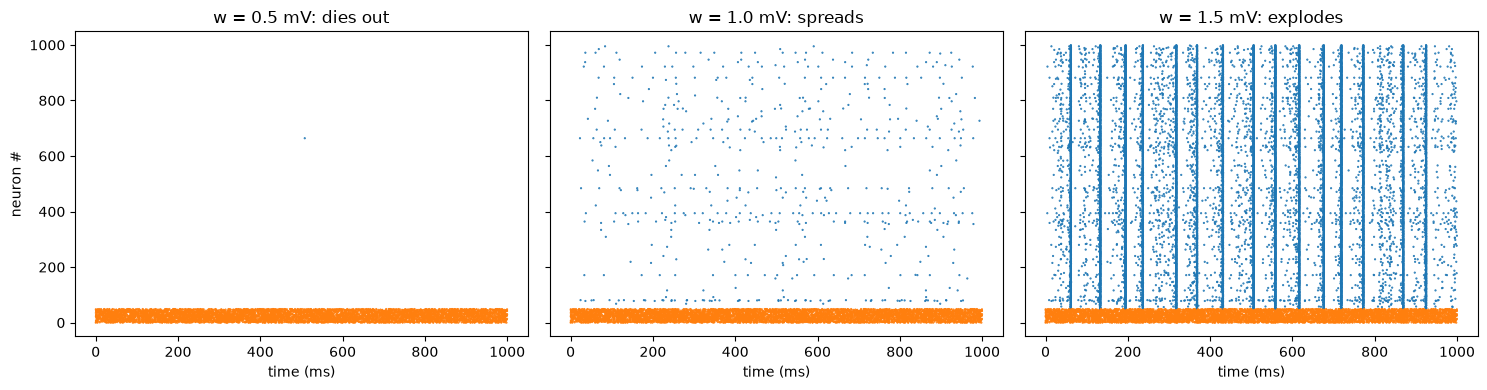

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, w, label in zip(axes, [0.5, 1.0, 1.5], ["dies out", "spreads", "explodes"]):
    counts, raster, _ = run_network_v2(w_mv=w, inh_frac=0)
    t_sp, n_sp = np.array(raster).T
    ax.scatter(t_sp, n_sp, s=0.3, c=np.where(n_sp < 50, "tab:orange", "tab:blue"))
    ax.set_title(f"w = {w} mV: {label}"); ax.set_xlabel("time (ms)")
axes[0].set_ylabel("neuron #")
plt.tight_layout(); plt.savefig("three_regimes_fixed.png", dpi=200); plt.show()